<a href="https://colab.research.google.com/github/Adeline187/Deep_Learning/blob/main/EXPT1/3Layer_Neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving t10k-images.idx3-ubyte to t10k-images.idx3-ubyte
Saving t10k-labels.idx1-ubyte to t10k-labels.idx1-ubyte
Saving train-images.idx3-ubyte to train-images.idx3-ubyte
Saving train-labels.idx1-ubyte to train-labels.idx1-ubyte


In [2]:
import os

print(os.listdir())

['.config', 't10k-images.idx3-ubyte', 't10k-labels.idx1-ubyte', 'train-images.idx3-ubyte', 'train-labels.idx1-ubyte', 'sample_data']


In [3]:
import numpy as np
import struct
import matplotlib.pyplot as plt

In [4]:
def load_images(filename):

    with open(filename, 'rb') as file:

        # Read header information
        magic_number, num_images, rows, cols = struct.unpack(
            '>IIII',
            file.read(16)
        )

        # Read image data
        images = np.frombuffer(
            file.read(),
            dtype=np.uint8
        )

        # Reshape images
        images = images.reshape(
            num_images,
            rows,
            cols
        )

        return images

In [5]:
def load_labels(filename):

    with open(filename, 'rb') as file:

        # Read header
        magic_number, num_labels = struct.unpack(
            '>II',
            file.read(8)
        )

        # Read labels
        labels = np.frombuffer(
            file.read(),
            dtype=np.uint8
        )

        return labels

In [6]:
X_train_images = load_images(
    'train-images.idx3-ubyte'
)

y_train = load_labels(
    'train-labels.idx1-ubyte'
)

X_test_images = load_images(
    't10k-images.idx3-ubyte'
)

y_test = load_labels(
    't10k-labels.idx1-ubyte'
)

In [7]:
print("Training images:", X_train_images.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test_images.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


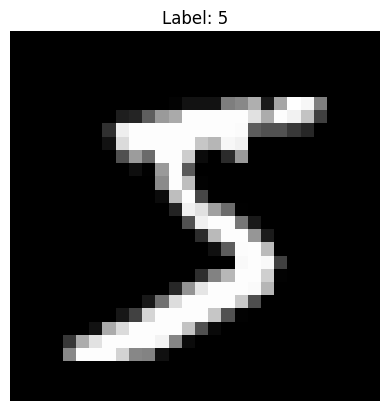

In [8]:
plt.imshow(
    X_train_images[0],
    cmap='gray'
)

plt.title(
    f"Label: {y_train[0]}"
)

plt.axis('off')
plt.show()

In [9]:
X_train = X_train_images.reshape(
    60000,
    784
)

X_test = X_test_images.reshape(
    10000,
    784
)

In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
input_size = 784
hidden_size = 128
output_size = 10

learning_rate = 0.01
epochs = 10
batch_size = 64

np.random.seed(42)

# Input Layer → Hidden Layer
W1 = np.random.randn(
    input_size,
    hidden_size
) * np.sqrt(2 / input_size)

b1 = np.zeros(
    (1, hidden_size)
)

# Hidden Layer → Output Layer
W2 = np.random.randn(
    hidden_size,
    output_size
) * np.sqrt(2 / hidden_size)

b2 = np.zeros(
    (1, output_size)
)

In [12]:
def relu(x):
    return np.maximum(0, x)

In [13]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [14]:
def softmax(x):

    exp_values = np.exp(
        x - np.max(
            x,
            axis=1,
            keepdims=True
        )
    )

    return exp_values / np.sum(
        exp_values,
        axis=1,
        keepdims=True
    )

In [15]:
def one_hot(labels, num_classes=10):

    onehot = np.zeros(
        (labels.size, num_classes)
    )

    onehot[
        np.arange(labels.size),
        labels
    ] = 1

    return onehot

In [16]:
Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

In [17]:
for epoch in range(epochs):

    # Shuffle the training data
    permutation = np.random.permutation(
        len(X_train)
    )

    X_train = X_train[permutation]
    Y_train = Y_train[permutation]

    # Mini-batch training
    for i in range(
        0,
        len(X_train),
        batch_size
    ):

        X_batch = X_train[
            i:i + batch_size
        ]

        Y_batch = Y_train[
            i:i + batch_size
        ]

        # =================================
        # FORWARD PROPAGATION
        # =================================

        # Input → Hidden Layer
        Z1 = np.dot(
            X_batch,
            W1
        ) + b1

        A1 = relu(Z1)

        # Hidden → Output Layer
        Z2 = np.dot(
            A1,
            W2
        ) + b2

        A2 = softmax(Z2)

        # =================================
        # BACKPROPAGATION
        # =================================

        m = X_batch.shape[0]

        # Output layer gradient
        dZ2 = (
            A2 - Y_batch
        ) / m

        dW2 = np.dot(
            A1.T,
            dZ2
        )

        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True
        )

        # Hidden layer gradient
        dA1 = np.dot(
            dZ2,
            W2.T
        )

        dZ1 = (
            dA1 *
            relu_derivative(Z1)
        )

        dW1 = np.dot(
            X_batch.T,
            dZ1
        )

        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True
        )

        # =================================
        # UPDATE WEIGHTS
        # =================================

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    # =================================
    # TEST THE NETWORK
    # =================================

    hidden_output = relu(
        np.dot(
            X_test,
            W1
        ) + b1
    )

    predictions_probability = softmax(
        np.dot(
            hidden_output,
            W2
        ) + b2
    )

    predictions = np.argmax(
        predictions_probability,
        axis=1
    )

    accuracy = np.mean(
        predictions == y_test
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Accuracy: "
        f"{accuracy * 100:.2f}%"
    )

Epoch 1/10 - Accuracy: 88.33%
Epoch 2/10 - Accuracy: 90.32%
Epoch 3/10 - Accuracy: 91.20%
Epoch 4/10 - Accuracy: 91.85%
Epoch 5/10 - Accuracy: 92.17%
Epoch 6/10 - Accuracy: 92.79%
Epoch 7/10 - Accuracy: 93.03%
Epoch 8/10 - Accuracy: 93.23%
Epoch 9/10 - Accuracy: 93.50%
Epoch 10/10 - Accuracy: 93.82%


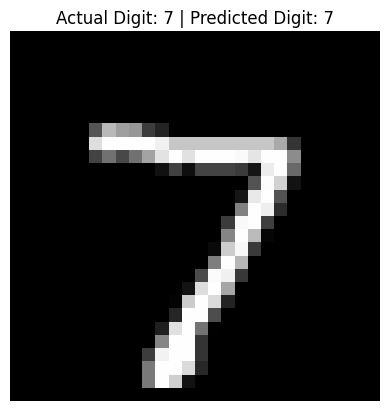

In [18]:
index = 0

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap='gray'
)

plt.title(
    f"Actual Digit: {y_test[index]} | "
    f"Predicted Digit: {predictions[index]}"
)

plt.axis('off')
plt.show()

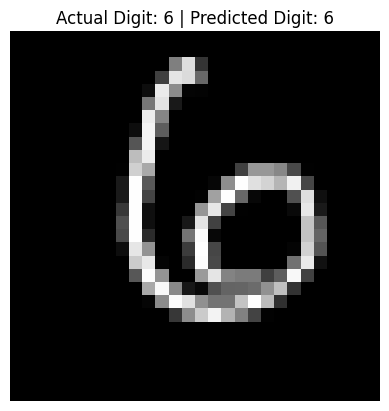

In [19]:
index = 100

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap='gray'
)

plt.title(
    f"Actual Digit: {y_test[index]} | "
    f"Predicted Digit: {predictions[index]}"
)

plt.axis('off')
plt.show()